<a href="https://colab.research.google.com/github/mink-47/Tobedoctor_VLM_STUDY/blob/main/VLM_1%E1%84%8C%E1%85%AE%E1%84%8E%E1%85%A1_%E1%84%85%E1%85%A1%E1%84%8B%E1%85%B5%E1%84%87%E1%85%B3%E1%84%8F%E1%85%A9%E1%84%83%E1%85%B5%E1%86%BC.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🩺 VLM 1주차 라이브 코딩 — Zero-shot 분류 실험실
투비닥터 의료 AI 심화 스터디 · VLM 파트

**오늘의 실험 스토리:**
1. Zero-shot 분류 첫 경험 (라벨 문장만으로 분류)
2. 프롬프트를 바꾸면 결과가 바뀐다 (프롬프트 민감성)
3. CheXzero 방식 흉내내기 (positive vs negative prompt)
4. 일반 이미지 vs 의료 이미지 (Domain Shift 체감)
5. 일반 CLIP vs 의료 특화 CLIP 비교 (오늘의 하이라이트!)
6. 미니 성능 평가 (과제 예고편)

In [2]:
!pip -q install transformers pillow

config.json:   0%|          | 0.00/4.19k [00:00<?, ?B/s]

pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  605MB            

pytorch_model.bin: downloading bytes:           |  0.00B            

model.safetensors: reconstructing file:   0%|          |  0.00B /  605MB            

model.safetensors: downloading bytes:           |  0.00B            

...

vocab.json:   0%|          | 0.00/862k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/525k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/2.22M [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/389 [00:00<?, ?B/s]

preprocessor_config.json:   0%|          | 0.00/316 [00:00<?, ?B/s]

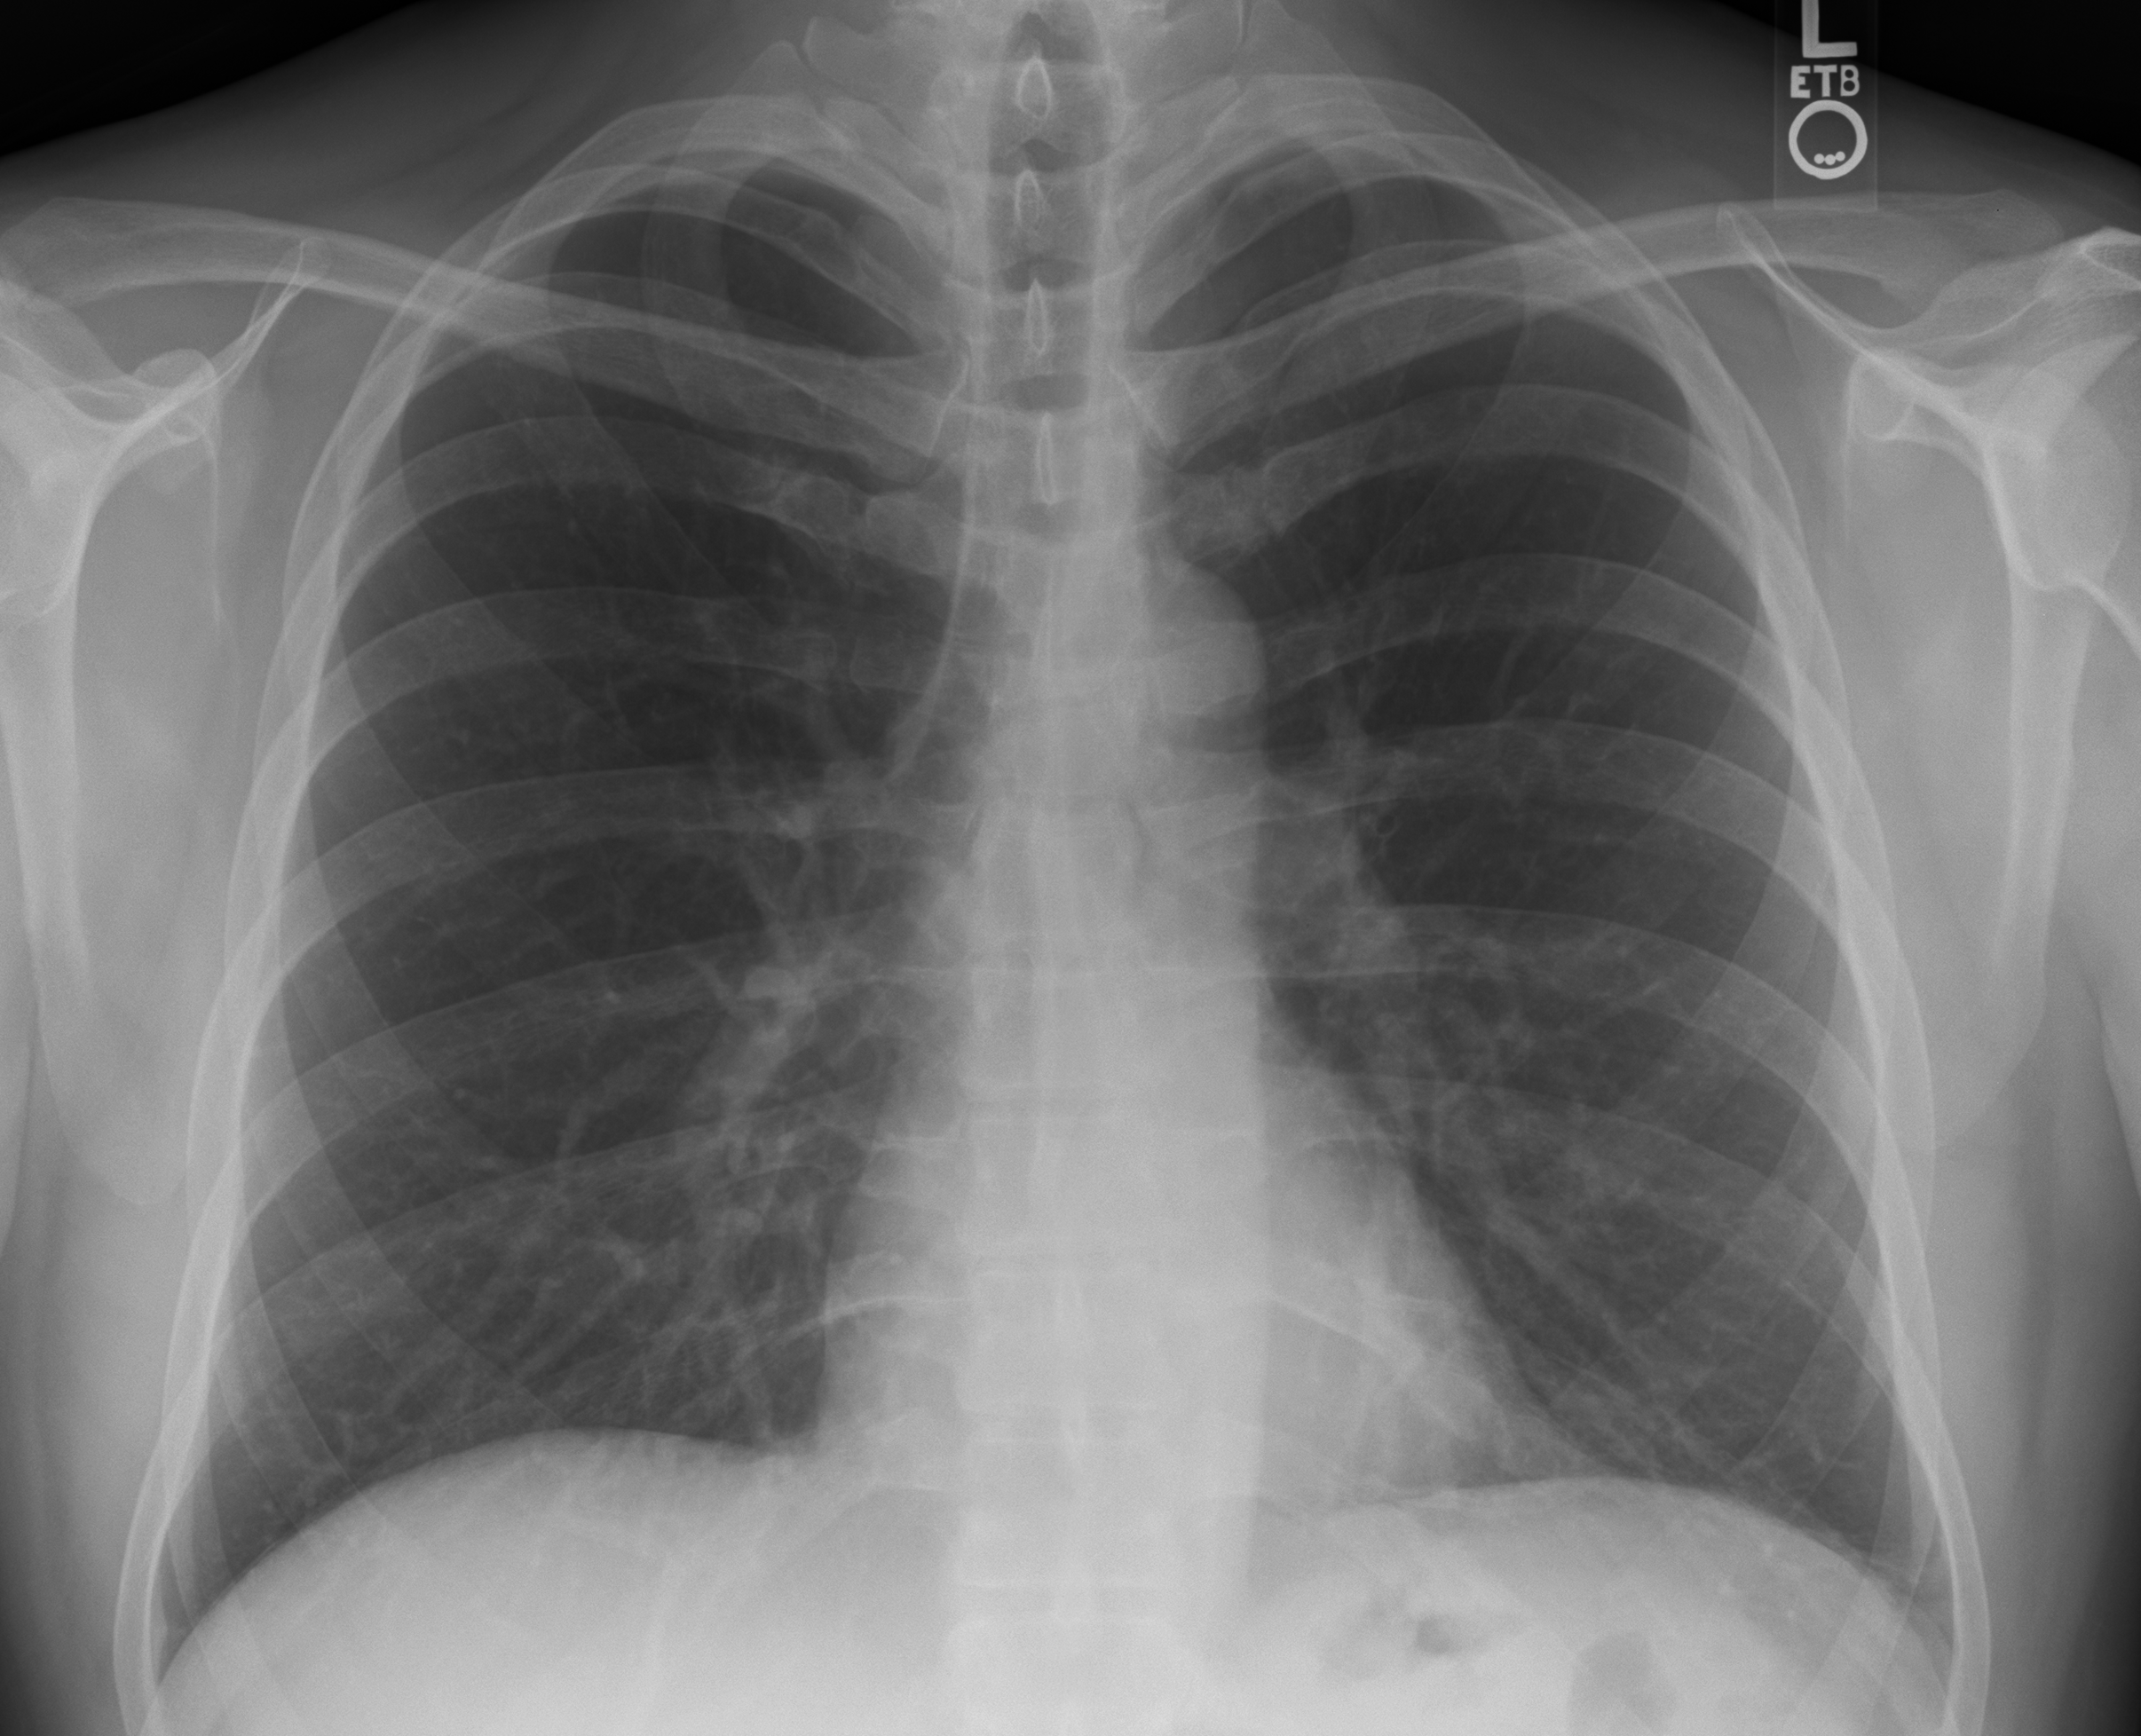

In [3]:
import requests
from io import BytesIO
from PIL import Image
from transformers import pipeline

clf = pipeline("zero-shot-image-classification",
               model="openai/clip-vit-base-patch32")

# 위키미디어 등은 User-Agent 없는 요청을 차단하므로, 직접 다운로드해서 PIL 이미지로 변환
def load_img(url):
    headers = {"User-Agent": "Mozilla/5.0 (study demo)"}
    r = requests.get(url, headers=headers, timeout=30)
    r.raise_for_status()
    return Image.open(BytesIO(r.content)).convert("RGB")

XRAY = load_img("https://commons.wikimedia.org/wiki/Special:FilePath/Chest_Xray_PA_3-8-2010.png")
XRAY  # 이미지가 화면에 출력되면 성공!

## 실험 1 — Zero-shot 분류 첫 경험
학습 없이 라벨 문장만으로 분류가 되는지 확인합니다.

In [4]:
labels = ["a chest X-ray", "a photo of a cat", "a brain MRI", "an abdominal CT scan"]
for r in clf(XRAY, candidate_labels=labels):
    print(f"{r['score']:.4f}  {r['label']}")

0.9980  a chest X-ray
0.0020  an abdominal CT scan
0.0000  a photo of a cat
0.0000  a brain MRI


**👀 관찰 포인트:** "a chest X-ray"에 압도적 점수 → X-ray 분류를 배운 적 없는 모델이 문장만으로 분류함. 이게 zero-shot!

## 실험 2 — 프롬프트 민감성
**같은 의미의 라벨을 표현만 바꿔서** 3번 돌려봅니다. 점수가 어떻게 변할까요?

In [5]:
prompt_sets = [
    ["pneumonia", "normal"],
    ["a photo of pneumonia", "a photo of a normal chest X-ray"],
    ["chest X-ray showing pneumonia", "chest X-ray with no abnormal findings"],
]
for labels in prompt_sets:
    res = clf(XRAY, candidate_labels=labels)
    print(f"[{' vs '.join(labels)}]")
    for r in res:
        print(f"   {r['score']:.4f}  {r['label']}")
    print()

[pneumonia vs normal]
   1.0000  pneumonia
   0.0000  normal

[a photo of pneumonia vs a photo of a normal chest X-ray]
   0.9469  a photo of a normal chest X-ray
   0.0531  a photo of pneumonia

[chest X-ray showing pneumonia vs chest X-ray with no abnormal findings]
   0.7549  chest X-ray showing pneumonia
   0.2451  chest X-ray with no abnormal findings



**👀 관찰 포인트:** 같은 이미지인데 **표현에 따라 점수·순위가 출렁**입니다. → 프롬프트 설계가 성능을 좌우한다 = "프롬프트 엔지니어링"이 연구 주제인 이유.

## 실험 3 — CheXzero 방식 흉내내기
PPT에서 본 positive prompt vs negative prompt 방식을 여러 병리에 반복 적용합니다.

In [6]:
pathologies = ["pneumonia", "pleural effusion", "cardiomegaly", "pneumothorax"]
for p in pathologies:
    res = clf(XRAY, candidate_labels=[p, f"no {p}"])
    pos = [r for r in res if r["label"] == p][0]["score"]
    print(f"{p:20s}  positive score: {pos:.3f}  {'⚠️ 양성 쪽으로 기움' if pos > 0.5 else ''}")

pneumonia             positive score: 0.889  ⚠️ 양성 쪽으로 기움
pleural effusion      positive score: 0.489  
cardiomegaly          positive score: 0.317  
pneumothorax          positive score: 0.400  


**👀 관찰 포인트:** CheXzero가 병리마다 {질환} vs no {질환}으로 물었던 방식 그대로입니다. 단, 이 점수는 **실제 질병 확률이 아니라는 것**(임상 검증 전!)을 기억하세요.

## 실험 4 — Domain Shift 체감
같은 모델에게 일반 이미지와 의료 이미지를 각각 세밀하게 물어봅니다.

In [7]:
# 4-1. 일반 이미지: 세밀한 구분도 잘하는지
CAT = load_img("https://commons.wikimedia.org/wiki/Special:FilePath/Cat03.jpg")
print("=== 일반 이미지 (품종 구분) ===")
for r in clf(CAT, candidate_labels=["a tabby cat", "a siamese cat", "a dog", "a rabbit"]):
    print(f"{r['score']:.4f}  {r['label']}")

# 4-2. 의료 이미지: 병리 구분 시켜보기
print("\n=== 의료 이미지 (병리 구분) ===")
for r in clf(XRAY, candidate_labels=["normal chest X-ray", "pneumonia", "pleural effusion", "cardiomegaly"]):
    print(f"{r['score']:.4f}  {r['label']}")

=== 일반 이미지 (품종 구분) ===
0.9622  a tabby cat
0.0249  a siamese cat
0.0118  a dog
0.0011  a rabbit

=== 의료 이미지 (병리 구분) ===
0.7411  normal chest X-ray
0.1134  pleural effusion
0.1052  pneumonia
0.0403  cardiomegaly


**👀 관찰 포인트:** 일반 이미지에선 자신 있게 구분하지만, 병리 구분에서는 점수가 **애매하게 분산**되는 경향이 보일 겁니다. 인터넷 이미지로 배운 모델에게 병변의 미세한 차이는 어렵다 → **Domain Shift**.

## 실험 5 — 🔥 일반 CLIP vs 의료 특화 CLIP (BiomedCLIP)
그럼 **의료 데이터(PubMed 논문 그림 1,500만 장)로 학습한 CLIP**은 다를까요? 오늘의 하이라이트입니다.

In [8]:
!pip -q install open_clip_torch

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 20.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 2.6 MB/s eta 0:00:00


In [9]:
import torch, open_clip

bio_model, preprocess = open_clip.create_model_from_pretrained(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')
bio_tok = open_clip.get_tokenizer(
    'hf-hub:microsoft/BiomedCLIP-PubMedBERT_256-vit_base_patch16_224')

def biomed_classify(pil_image, labels):
    image = preprocess(pil_image).unsqueeze(0)
    texts = bio_tok([f"this is a photo of {l}" for l in labels])
    with torch.no_grad():
        img_f = bio_model.encode_image(image)
        txt_f = bio_model.encode_text(texts)
        img_f /= img_f.norm(dim=-1, keepdim=True)
        txt_f /= txt_f.norm(dim=-1, keepdim=True)
        probs = (100 * img_f @ txt_f.T).softmax(dim=-1)[0]
    return sorted(zip(labels, probs.tolist()), key=lambda x: -x[1])

labels = ["normal chest X-ray", "pneumonia", "pleural effusion", "cardiomegaly"]

print("=== 일반 CLIP ===")
for r in clf(XRAY, candidate_labels=labels):
    print(f"{r['score']:.4f}  {r['label']}")

print("\n=== BiomedCLIP (의료 특화) ===")
for l, s in biomed_classify(XRAY, labels):
    print(f"{s:.4f}  {l}")

open_clip_config.json:   0%|          | 0.00/707 [00:00<?, ?B/s]

open_clip_pytorch_model.bin: reconstructing file:   0%|          |  0.00B /  784MB            

open_clip_pytorch_model.bin: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/385 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/28.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/225k [00:00<?, ?B/s]

=== 일반 CLIP ===
0.7411  normal chest X-ray
0.1134  pleural effusion
0.1052  pneumonia
0.0403  cardiomegaly

=== BiomedCLIP (의료 특화) ===
1.0000  normal chest X-ray
0.0000  pneumonia
0.0000  pleural effusion
0.0000  cardiomegaly


**👀 관찰 포인트:** 같은 이미지·같은 라벨인데 두 모델의 확신 분포가 다릅니다. **"어떤 데이터로 학습했는가"가 도메인 성능을 결정**한다는 것 — 다음 주 LLaVA-Med(의료 특화 VLM)를 배우는 이유가 바로 이겁니다.

## 실험 6 — 미니 성능 평가 (과제 예고편)
이미지 여러 장에 대해 예측을 모아보면 그게 곧 성능 평가입니다. 과제(의료 이미지 5장 비교)를 이 틀로 하면 돼요.

In [10]:
test_images = {
    "chest X-ray": XRAY,
    "cat photo":  CAT,
    # 과제: 여기에 본인이 찾은 의료 이미지를 추가해보세요!
    # "my image 1": load_img("https://..."),
}
labels = ["a chest X-ray", "a photo of a cat", "a brain MRI"]

print(f"{'이미지':15s} {'예측':25s} {'confidence':>10s}")
print("-" * 55)
for name, img in test_images.items():
    top = clf(img, candidate_labels=labels)[0]
    print(f"{name:15s} {top['label']:25s} {top['score']:>10.4f}")

이미지             예측                        confidence
-------------------------------------------------------
chest X-ray     a chest X-ray                 1.0000
cat photo       a photo of a cat              1.0000


## 📝 오늘의 결론 3줄

1. **Zero-shot**: 라벨 문장만 바꾸면 재학습 없이 분류가 된다 (CLIP의 힘)
2. **프롬프트 민감성**: 같은 이미지도 문장 표현에 따라 결과가 달라진다
3. **Domain Shift**: 일반 CLIP은 병리의 미세한 구분에 약하다 → 의료 특화 모델(BiomedCLIP, 다음 주 LLaVA-Med)이 필요한 이유

### 📌 이번 주 과제
의료 이미지 5장을 골라 (구글/위키미디어 검색) 정상/폐렴/기타 라벨로 zero-shot 분류를 돌려보고, 결과 캡처 + 느낀 점 한 줄을 GitHub repo(또는 톡방)에 올려주세요.
**보너스**: 실험 5처럼 BiomedCLIP과 결과를 비교해보면 최고!